# Introduction au ML — Séance 5 (TP)
## Prédire un nombre : la régression linéaire, de l'équation normale à Ridge

**Dr. El Hadji Bassirou TOURÉ** · DMI · FST · UCAD

***

La Séance 3 a prédit une *classe* ; la Séance 4 a appris à préparer les données. Ce TP
prédit une **quantité** — la durée d'hospitalisation, en jours. Au programme, refait
**à la main** puis confronté à scikit-learn : la MSE, l'**équation normale**, la
**descente de gradient** codée pas à pas, les métriques MAE/RMSE/R², la **courbe en U**
du sur-ajustement et **Ridge** qui la dompte.

**Durée estimée : 1h30.** Exécuter les cellules dans l'ordre, de haut en bas.

## Partie 0 — Mise en place

Les outils, puis le générateur DataSANTÉ-221 — le même qu'aux séances précédentes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 3)
print("Outils prêts. NumPy", np.__version__, "· pandas", pd.__version__)

Outils prêts. NumPy 2.4.4 · pandas 3.0.2


In [2]:
# Ne pas modifier cette cellule : générateur officiel DataSANTÉ-221
def generate_datasante221(n=10_000, seed=221):
    rng = np.random.default_rng(seed)
    age = np.clip(rng.gamma(2.5, 14, n), 5, 85).round(0).astype(int)
    glycemie = np.clip(rng.normal(5.5 + 0.05*age, 1.8), 3.0, 18.0).round(1)
    hemoglobine = np.clip(rng.normal(12.5 - 0.02*age, 1.5), 6.0, 17.0).round(1)
    fievre = np.clip(rng.normal(37.5, 0.9, n), 36.0, 41.5).round(1)
    saison = rng.choice([0, 1], size=n, p=[0.55, 0.45])
    duree = (1.0 + 0.05*age + 0.6*glycemie - 0.3*hemoglobine
             + 1.5*saison + rng.normal(0, 1.8, n)).clip(0.5, 30).round(1)
    proba_palu = 1/(1+np.exp(-(-3 + 1.5*saison + 0.8*(fievre>38.5))))
    palu = (rng.uniform(0,1,n) < proba_palu).astype(int)
    return pd.DataFrame({'age':age,'glycemie':glycemie,'hemoglobine':hemoglobine,
                         'fievre':fievre,'saison':saison,
                         'duree_hospit_j':duree,'paludisme':palu})

df = generate_datasante221()
print("dimensions :", df.shape)

dimensions : (10000, 7)


In [3]:
# La cible du jour est continue : la durée d'hospitalisation, en jours
df[["age", "glycemie", "hemoglobine", "fievre", "saison", "duree_hospit_j"]].head(3)

,age,glycemie,hemoglobine,fievre,saison,duree_hospit_j
0,47,9.3,11.8,38.0,0,3.8
1,18,5.1,13.0,39.5,1,0.5
2,56,7.2,9.5,37.1,1,6.5


In [4]:
# Un vecteur y qui vit dans R, plus dans {0, 1}
y_apercu = df["duree_hospit_j"]
print("moyenne :", round(y_apercu.mean(), 2), "jours · médiane :", y_apercu.median(),
      "· min :", y_apercu.min(), "· max :", y_apercu.max())

moyenne : 4.32 jours · médiane : 4.1 · min : 0.5 · max : 15.3


**Lecture.** La matrice $X$ est inchangée depuis la Séance 3 ; la nouveauté est dans $y$ :
des réels entre $0{,}5$ et $15{,}3$ jours. L'erreur ne sera plus « correct/incorrect » mais
une **distance** — d'où de nouvelles métriques.

## Partie 1 — Le jouet et la MSE

Tout le formalisme de la séance se vérifie d'abord sur un **jouet de quatre patients** :
$x = [1, 2, 3, 4]$ (une caractéristique) et $y = [2, 2, 4, 5]$ (la durée).

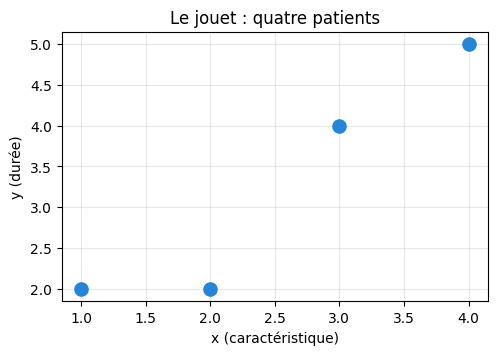

In [5]:
# Le jouet : quatre patients, une caractéristique
x_j = np.array([1., 2., 3., 4.])
y_j = np.array([2., 2., 4., 5.])

plt.figure(figsize=(5.5, 3.5))
plt.scatter(x_j, y_j, s=90, color="#2585D6", zorder=3)
plt.xlabel("x (caractéristique)"); plt.ylabel("y (durée)")
plt.title("Le jouet : quatre patients"); plt.grid(alpha=0.3)
plt.show()

Le deck propose la droite $\hat y = 0{,}5 + 1{,}1\,x$. La **MSE** juge cette droite :
résidus $r_i = y_i - \hat y_i$, carrés, moyenne.

In [6]:
# La MSE de la droite candidate 0,5 + 1,1 x — à la main
b, w = 0.5, 1.1
y_chapeau = b + w * x_j
residus = y_j - y_chapeau
print("prédictions :", y_chapeau)
print("résidus     :", residus)
print("carrés      :", residus**2)
print("MSE         :", np.mean(residus**2))

prédictions : [1.6 2.7 3.8 4.9]
résidus     : [ 0.4 -0.7  0.2  0.1]
carrés      : [0.16 0.49 0.04 0.01]
MSE         : 0.175


In [7]:
# La même MSE pour la droite plate (toujours répondre la moyenne)
y_plat = np.full(4, y_j.mean())
print("droite plate : y =", y_j.mean(), "partout")
print("MSE          :", np.mean((y_j - y_plat)**2))

droite plate : y = 3.25 partout
MSE          : 1.6875


**Lecture.** $0{,}175$ contre $1{,}688$ : la MSE départage sans ambiguïté — la droite
ajustée fait dix fois mieux que la droite paresseuse. Les deux nombres resserviront.

**Exercice.** Calculer, sur le même jouet, la MSE de la droite $\hat y = 1 + x$.
Le résultat attendu est $0{,}25$.

In [ ]:
# Calculer la MSE de la droite y = 1 + x sur le jouet

## Partie 2 — L'équation normale, à la main

Le minimum de la MSE se calcule **exactement**. D'abord les formules fermées à une
variable, puis la version matricielle — celle que `LinearRegression` applique.

In [9]:
# Formules fermées à une variable : écarts aux moyennes
x_bar, y_bar = x_j.mean(), y_j.mean()
numerateur = np.sum((x_j - x_bar) * (y_j - y_bar))
denominateur = np.sum((x_j - x_bar)**2)
w_main = numerateur / denominateur
b_main = y_bar - w_main * x_bar
print("numérateur :", numerateur, "· dénominateur :", denominateur)
print("w =", w_main, "· b =", b_main)

numérateur : 5.5 · dénominateur : 5.0
w = 1.1 · b = 0.5


In [10]:
# Version matricielle : la matrice augmentée (colonne de 1) et les deux blocs
X_tilde = np.column_stack([np.ones(4), x_j])
XtX = X_tilde.T @ X_tilde
Xty = X_tilde.T @ y_j
print("X_tilde =\n", X_tilde)
print("\nXtX =\n", XtX, "\n\nXty =", Xty)

X_tilde =
 [[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]]

XtX =
 [[ 4. 10.]
 [10. 30.]] 

Xty = [13. 38.]


In [11]:
# Résoudre l'équation normale : theta = (XtX)^-1 Xty
theta = np.linalg.solve(XtX, Xty)
print("inverse de XtX =\n", np.linalg.inv(XtX))
print("\ntheta = (b, w) =", theta)

inverse de XtX =
 [[ 1.5 -0.5]
 [-0.5  0.2]]

theta = (b, w) = [0.5 1.1]


In [12]:
# Confrontation : scikit-learn fait-il le même calcul ?
from sklearn.linear_model import LinearRegression

lr_jouet = LinearRegression().fit(x_j.reshape(-1, 1), y_j)
print("scikit-learn : intercept =", lr_jouet.intercept_, "· coef =", lr_jouet.coef_[0])
assert np.allclose(theta, [lr_jouet.intercept_, lr_jouet.coef_[0]])
print("identique à l'équation normale calculée à la main — vérifié.")

scikit-learn : intercept = 0.5 · coef = 1.1
identique à l'équation normale calculée à la main — vérifié.


**Lecture.** Trois chemins — formules fermées, équation normale, `LinearRegression` —
un seul point d'arrivée : $(\hat b, \hat w) = (0{,}5\,;\,1{,}1)$. La solution exacte existe
et l'outil ne fait rien d'autre que ce calcul.

**Exercice.** Sur un autre jeu, on a obtenu
$\tilde X^\top\tilde X = \begin{pmatrix}2 & 3\\ 3 & 5\end{pmatrix}$ et
$\tilde X^\top y = \begin{pmatrix}4\\ 7\end{pmatrix}$.
Résoudre l'équation normale avec `np.linalg.solve`. Le résultat attendu est $(-1, 2)$.

In [ ]:
# Résoudre l'équation normale pour XtX = [[2, 3], [3, 5]] et Xty = [4, 7]

## Partie 3 — La descente de gradient, codée pas à pas

Quand la solution exacte coûte trop cher (colinéarité, très grande dimension), on
**descend la cuvette** : $\theta \leftarrow \theta - \eta\,\nabla J(\theta)$, avec
pour la MSE des gradients qui ne sont que des moyennes de résidus :
$\partial J/\partial b = -\tfrac{2}{n}\sum r_i$ et
$\partial J/\partial w = -\tfrac{2}{n}\sum x_i r_i$.

In [14]:
# La descente de gradient en sept lignes
def descente(eta, n_iter, b0=0.0, w0=0.0):
    b, w, histoire = b0, w0, []
    for t in range(n_iter):
        r = y_j - (b + w * x_j)               # résidus au point courant
        grad_b = -2 * np.mean(r)              # pente de J selon b
        grad_w = -2 * np.mean(x_j * r)        # pente de J selon w
        b, w = b - eta * grad_b, w - eta * grad_w
        histoire.append((b, w, np.mean((y_j - (b + w * x_j))**2)))
    return np.array(histoire)

hist = descente(eta=0.1, n_iter=300)
print("it 1 :", hist[0])   # attendu : b=0.65, w=1.9, J=5.60
print("it 2 :", hist[1])
print("it 3 :", hist[2])

it 1 : [0.65   1.9    5.5975]
it 2 : [0.22   0.625  2.6106]
it 3 : [0.5135 1.4775 1.2695]


it 10  : [0.4097 1.1075 0.1802]
it 100 : [0.4946 1.1018 0.175 ]
it 300 : [0.5   1.1   0.175]  <- la solution de l'équation normale, retrouvée


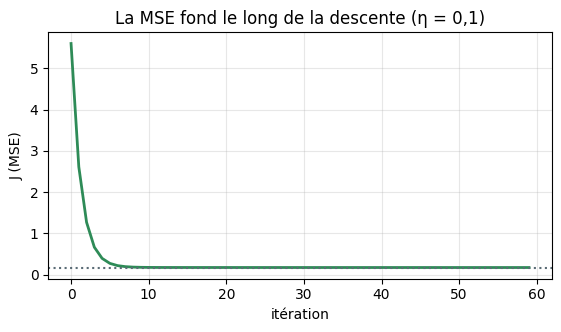

In [15]:
# La trajectoire complète : J fond, (b, w) convergent
print("it 10  :", hist[9])
print("it 100 :", hist[99])
print("it 300 :", hist[299], " <- la solution de l'équation normale, retrouvée")

plt.figure(figsize=(6.5, 3.2))
plt.plot(hist[:60, 2], color="#2E8B57", lw=2)
plt.axhline(0.175, color="#5A6B75", ls=":")
plt.xlabel("itération"); plt.ylabel("J (MSE)")
plt.title("La MSE fond le long de la descente (η = 0,1)"); plt.grid(alpha=0.3)
plt.show()

**Lecture.** Itération 1 : gradients $(-6{,}5\,;\,-19)$, le pas catapulte $(b,w)$ à
$(0{,}65\,;\,1{,}9)$ — trop loin ; l'itération 2 sur-corrige en sens inverse : le
**zigzag**. Mais chaque rebond rétrécit et, à l'itération 300, la descente s'immobilise sur
$(0{,}5\,;\,1{,}1)$ : le point exact de l'équation normale. Deux algorithmes, un même fond
de cuvette.

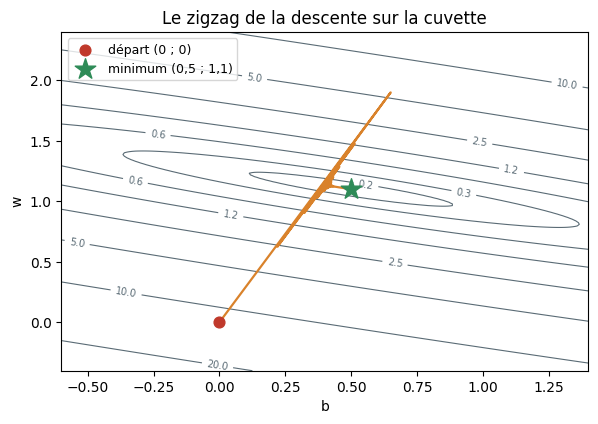

In [16]:
# La trajectoire vue de dessus : les courbes de niveau de J(b, w)
bs, ws = np.meshgrid(np.linspace(-0.6, 1.4, 200), np.linspace(-0.4, 2.4, 200), indexing="ij")
J_grille = np.mean((y_j[None, None, :] - (bs[:, :, None] + ws[:, :, None]*x_j[None, None, :]))**2, axis=2)

plt.figure(figsize=(6.8, 4.4))
cs = plt.contour(bs, ws, J_grille, levels=[0.2, 0.3, 0.6, 1.2, 2.5, 5, 10, 20], colors="#5A6B75", linewidths=0.8)
plt.clabel(cs, fontsize=7)
traj = np.vstack([[0, 0], hist[:, :2]])
plt.plot(traj[:, 0], traj[:, 1], color="#D9822B", lw=1.6)
plt.scatter([0], [0], color="#C0392B", s=60, label="départ (0 ; 0)", zorder=4)
plt.scatter([0.5], [1.1], marker="*", s=240, color="#2E8B57", label="minimum (0,5 ; 1,1)", zorder=4)
plt.xlabel("b"); plt.ylabel("w"); plt.legend(fontsize=9)
plt.title("Le zigzag de la descente sur la cuvette"); plt.show()

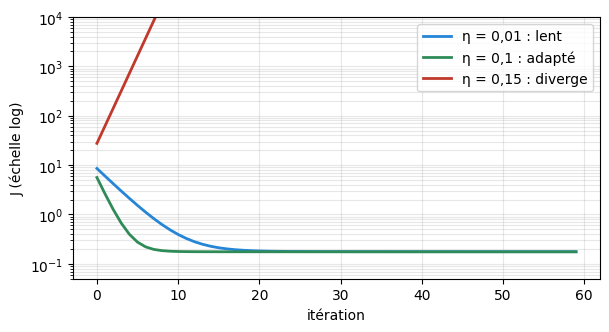

J à l'itération 20 pour η = 0,15 : 152871435.7166353


In [17]:
# Le pas eta décide de tout : trop petit, adapté, trop grand
plt.figure(figsize=(6.8, 3.4))
for eta, couleur, etiquette in [(0.01, "#2585D6", "η = 0,01 : lent"),
                                (0.10, "#2E8B57", "η = 0,1 : adapté"),
                                (0.15, "#C0392B", "η = 0,15 : diverge")]:
    plt.plot(descente(eta, 60)[:, 2], color=couleur, lw=2, label=etiquette)
plt.yscale("log"); plt.ylim(5e-2, 1e4)
plt.xlabel("itération"); plt.ylabel("J (échelle log)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.show()

print("J à l'itération 20 pour η = 0,15 :", descente(0.15, 20)[-1, 2])

**Lecture.** $\eta = 0{,}01$ descend mais lambine ; $\eta = 0{,}1$ atteint le fond en
vingt pas ; $\eta = 0{,}15$ **diverge** — $J$ dépasse $10^{8}$ en vingt itérations. Le pas
ne choisit pas la direction (le gradient s'en charge), seulement la longueur de l'enjambée.

**Exercice.** Relancer `descente` avec $\eta = 0{,}05$ et compter, à l'aide de
l'historique, le nombre d'itérations nécessaires pour passer sous $J < 0{,}18$. Comparer
avec $\eta = 0{,}1$.

In [ ]:
# Avec eta = 0,05 : combien d'itérations pour J < 0,18 ?

### Le pont scikit-learn : `SGDRegressor`

`LinearRegression` résout l'équation normale ; `SGDRegressor` descend le gradient
(variante *stochastique* : pente estimée sur des sous-échantillons). Comme tout
algorithme à descente, il exige des variables **standardisées** — la cuvette doit être
ronde (Séance 4).

In [19]:
# Les deux solveurs sur DataSANTÉ-221 : même cible, deux chemins
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

colonnes = ["age", "glycemie", "hemoglobine", "fievre", "saison"]
X = df[colonnes]
y = df["duree_hospit_j"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

exact = LinearRegression().fit(X_train, y_train)
iteratif = make_pipeline(StandardScaler(),
                         SGDRegressor(max_iter=1000, random_state=0)).fit(X_train, y_train)
print("R² test — équation normale     :", round(exact.score(X_test, y_test), 4))
print("R² test — descente de gradient :", round(iteratif.score(X_test, y_test), 4))

R² test — équation normale     : 0.598
R² test — descente de gradient : 0.5988


**Lecture.** Deux R² quasi identiques : même cuvette, même fond. Sur $5$ variables,
l'équation normale est imbattable ; la descente prendra le relais quand les variables se
compteront en milliers — et elle sera *le seul* chemin des réseaux de neurones.

## Partie 4 — MAE, RMSE et R², à la main

Trois métriques pour un nombre : deux en jours (MAE, RMSE), une sans unité (R²,
comparaison à la baseline-moyenne).

In [20]:
# MAE et RMSE sur l'exemple du deck : erreurs absolues (1, 1, 1, 1, 6)
erreurs = np.array([1., 1., 1., 1., 6.])
mae = np.mean(erreurs)
rmse = np.sqrt(np.mean(erreurs**2))
print("MAE  :", mae, "jours")
print("RMSE :", round(rmse, 2), "jours  <- le carré surtaxe la grande erreur")

MAE  : 2.0 jours
RMSE : 2.83 jours  <- le carré surtaxe la grande erreur


In [21]:
# Le R² du jouet, décomposé — puis vérifié contre scikit-learn
from sklearn.metrics import r2_score

ss_res = np.sum((y_j - (0.5 + 1.1*x_j))**2)     # erreur du modèle
ss_tot = np.sum((y_j - y_j.mean())**2)          # erreur de la moyenne
r2_main = 1 - ss_res/ss_tot
print("SS_res =", ss_res, "· SS_tot =", ss_tot, "· R² =", round(r2_main, 4))
assert np.isclose(r2_main, r2_score(y_j, 0.5 + 1.1*x_j))
print("identique à r2_score — vérifié.")

SS_res = 0.7 · SS_tot = 6.75 · R² = 0.8963
identique à r2_score — vérifié.


**Exercice.** Calculer à la main le R² de la **droite plate** ($\hat y = \bar y$
partout) sur le jouet. Avant de calculer, prédire le résultat : que vaut $SS_{res}$ dans
ce cas particulier ?

In [ ]:
# Le R² de la droite plate sur le jouet

## Partie 5 — DataSANTÉ-221 : prédire la durée d'hospitalisation

Le protocole complet de la Séance 3, version régression.

In [23]:
# Entraînement et bilan chiffré
from sklearn.metrics import mean_absolute_error, mean_squared_error

modele = LinearRegression().fit(X_train, y_train)
y_pred = modele.predict(X_test)
print("MAE  :", round(mean_absolute_error(y_test, y_pred), 2), "jours")
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2), "jours")
print("R²   :", round(r2_score(y_test, y_pred), 3))

MAE  : 1.35 jours
RMSE : 1.67 jours
R²   : 0.598


In [24]:
# Les coefficients se lisent en clair
pd.DataFrame({"poids": modele.coef_}, index=colonnes).round(3)

,poids
age,0.048
glycemie,0.566
hemoglobine,-0.263
fievre,0.011
saison,1.379


**Lecture.** Le modèle se trompe de $1{,}35$ jour en moyenne et efface $60\,\%$ de
l'erreur de la baseline. Et ses poids racontent les données : $+0{,}57$ jour par mmol/L de
glycémie, $+1{,}38$ jour en hivernage, $-0{,}26$ par g/dL d'hémoglobine, fièvre quasi nulle
*pour cette cible* — le modèle linéaire s'explique, c'est son grand luxe.

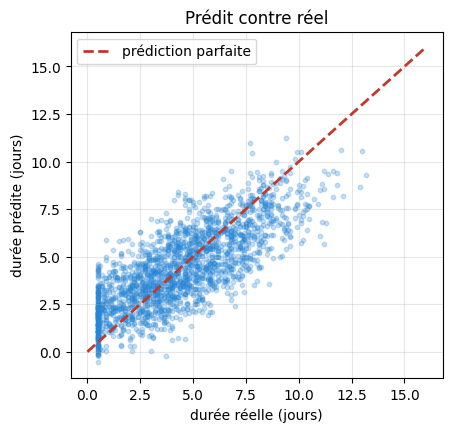

In [25]:
# Diagnostic visuel 1 : prédit contre réel
plt.figure(figsize=(4.8, 4.5))
plt.scatter(y_test, y_pred, s=10, alpha=0.25, color="#2585D6")
plt.plot([0, 16], [0, 16], color="#C0392B", ls="--", lw=2, label="prédiction parfaite")
plt.xlabel("durée réelle (jours)"); plt.ylabel("durée prédite (jours)")
plt.legend(); plt.title("Prédit contre réel"); plt.grid(alpha=0.3)
plt.show()

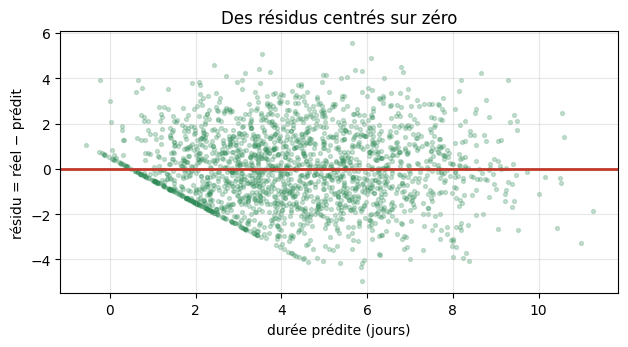

In [26]:
# Diagnostic visuel 2 : les résidus en fonction du prédit
residus_test = y_test - y_pred
plt.figure(figsize=(7.2, 3.4))
plt.scatter(y_pred, residus_test, s=8, alpha=0.25, color="#2E8B57")
plt.axhline(0, color="#C0392B", lw=2)
plt.xlabel("durée prédite (jours)"); plt.ylabel("résidu = réel − prédit")
plt.title("Des résidus centrés sur zéro"); plt.grid(alpha=0.3)
plt.show()

In [27]:
# Le linéaire face à la baseline et à l'arbre de la Séance 3
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor

for nom, m in [("baseline (moyenne)", DummyRegressor()),
               ("arbre prof. 5", DecisionTreeRegressor(max_depth=5, random_state=0)),
               ("régression linéaire", modele)]:
    if nom != "régression linéaire":
        m.fit(X_train, y_train)
    print(f"{nom:22s} : R² test = {m.score(X_test, y_test):.3f}")

baseline (moyenne)     : R² test = -0.001
arbre prof. 5          : R² test = 0.533
régression linéaire    : R² test = 0.598


**Lecture.** Sur cette cible, le linéaire ($0{,}598$) **devance l'arbre** ($0{,}533$) :
la durée est fabriquée par des effets additifs — terrain naturel d'une somme pondérée.
Chaque famille de modèles a ses terrains ; aucune ne gagne partout.

**Exercice.** Entraîner un `DecisionTreeRegressor` de profondeur $10$ et afficher son
R² sur le **train** et sur le **test**. Diagnostiquer ce que montre l'écart entre les
deux (vocabulaire de la Séance 3).

In [ ]:
# Arbre de profondeur 10 : R² train et R² test, puis diagnostic

## Partie 6 — Le degré du polynôme : la courbe en U

Quand la relation est courbe, on enrichit les entrées : $x, x^2, \dots, x^p$. Le degré
$p$ devient un **bouton de complexité** — et le sur-ajustement guette. Démonstration sur
une sinusoïde bruitée de trente points.

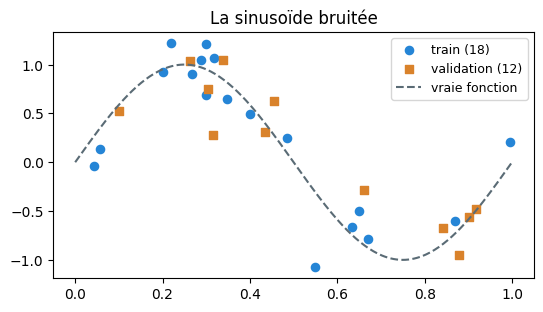

In [29]:
# Une vraie fonction courbe + du bruit : 18 points de train, 12 de validation
rng = np.random.default_rng(221)
x_sin = np.sort(rng.uniform(0, 1, 30))
y_sin = np.sin(2*np.pi*x_sin) + rng.normal(0, 0.25, 30)
x_tr, x_va, y_tr, y_va = train_test_split(x_sin, y_sin, test_size=0.4, random_state=0)

plt.figure(figsize=(6.2, 3.2))
grille = np.linspace(0, 1, 300)
plt.scatter(x_tr, y_tr, s=35, color="#2585D6", label="train (18)")
plt.scatter(x_va, y_va, s=35, color="#D9822B", marker="s", label="validation (12)")
plt.plot(grille, np.sin(2*np.pi*grille), color="#5A6B75", ls="--", label="vraie fonction")
plt.legend(fontsize=9); plt.title("La sinusoïde bruitée"); plt.show()

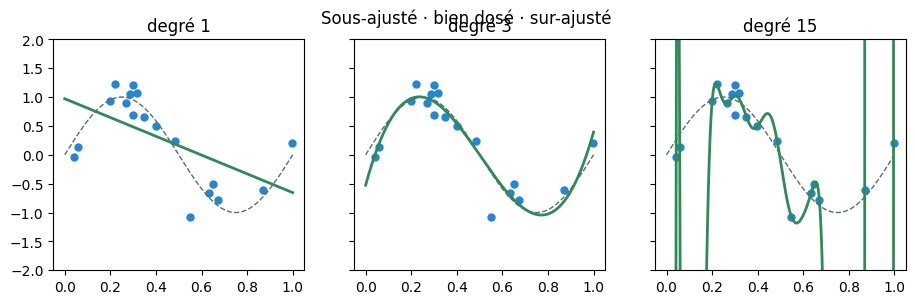

In [30]:
# Trois degrés, trois destins
from sklearn.preprocessing import PolynomialFeatures

fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, deg in zip(axes, [1, 3, 15]):
    m = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(x_tr.reshape(-1, 1), y_tr)
    ax.scatter(x_tr, y_tr, s=25, color="#2585D6")
    ax.plot(grille, np.sin(2*np.pi*grille), color="#5A6B75", ls="--", lw=1)
    ax.plot(grille, m.predict(grille.reshape(-1, 1)), color="#2E8B57", lw=2)
    ax.set_ylim(-2, 2); ax.set_title(f"degré {deg}")
plt.suptitle("Sous-ajusté · bien dosé · sur-ajusté"); plt.show()

In [31]:
# La courbe en U : RMSE train et validation pour les degrés 1 à 15
resultats = []
for deg in range(1, 16):
    m = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(x_tr.reshape(-1, 1), y_tr)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, m.predict(x_tr.reshape(-1, 1))))
    rmse_va = np.sqrt(mean_squared_error(y_va, m.predict(x_va.reshape(-1, 1))))
    resultats.append((deg, rmse_tr, rmse_va))
table_u = pd.DataFrame(resultats, columns=["degré", "RMSE train", "RMSE validation"])
table_u.round(3)

,degré,RMSE train,RMSE validation
0,1,0.597,0.335
1,2,0.597,0.330
2,3,0.244,0.287
3,4,0.222,0.323
4,5,0.222,0.330
5,6,0.212,0.329
6,7,0.202,0.349
7,8,0.195,0.665
8,9,0.195,0.395
9,10,0.155,10.968


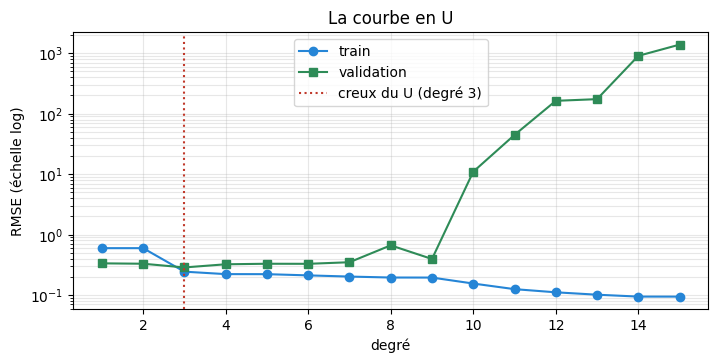

In [32]:
# La même table, en image
plt.figure(figsize=(8.2, 3.6))
plt.plot(table_u["degré"], table_u["RMSE train"], "-o", color="#2585D6", label="train")
plt.plot(table_u["degré"], table_u["RMSE validation"], "-s", color="#2E8B57", label="validation")
plt.axvline(3, color="#C0392B", ls=":", label="creux du U (degré 3)")
plt.yscale("log"); plt.xlabel("degré"); plt.ylabel("RMSE (échelle log)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.title("La courbe en U"); plt.show()

**Lecture.** La RMSE de train **descend toujours** — de $0{,}60$ à $0{,}09$ : plus de
complexité ne peut que mieux coller au train. La validation, elle, atteint son creux au
degré $3$ ($0{,}287$) puis **explose** — $1386$ au degré $15$. À ne regarder que le train,
on choisirait le pire modèle. Seule une donnée jamais vue dit la vérité.

**Exercice.** Dans la table `table_u`, identifier par le code le degré qui minimise la
RMSE de **validation** (`idxmin`), puis celui qui minimise la RMSE de **train**.
Constater qu'ils ne coïncident pas.

In [ ]:
# Degré du minimum en validation, degré du minimum en train

## Partie 7 — Ridge : l'explosion domptée

Le degré 15 qui explose cache un symptôme : des **coefficients géants**. Ridge ajoute un
loyer sur les poids — $J_{ridge} = \text{MSE} + \alpha\sum_j w_j^2$ — et les ramène à la
raison.

In [34]:
# Le symptôme : le plus grand coefficient du degré 15 sans pénalité
sans_penalite = make_pipeline(PolynomialFeatures(15), StandardScaler(),
                              LinearRegression()).fit(x_tr.reshape(-1, 1), y_tr)
coefs_libres = sans_penalite.named_steps["linearregression"].coef_
print("plus grand |coefficient| :", f"{np.abs(coefs_libres).max():,.0f}")
print("RMSE validation :", round(np.sqrt(mean_squared_error(
    y_va, sans_penalite.predict(x_va.reshape(-1, 1)))), 1))

plus grand |coefficient| : 9,188,339,655
RMSE validation : 1389.2


In [35]:
# Le remède : le même degré 15, sous trois doses de Ridge
from sklearn.linear_model import Ridge

for alpha in [0.001, 0.1, 100]:
    m = make_pipeline(PolynomialFeatures(15), StandardScaler(),
                      Ridge(alpha=alpha)).fit(x_tr.reshape(-1, 1), y_tr)
    coefs = m.named_steps["ridge"].coef_
    rmse_va = np.sqrt(mean_squared_error(y_va, m.predict(x_va.reshape(-1, 1))))
    print(f"alpha = {alpha:7} : max|w| = {np.abs(coefs).max():8.2f} · RMSE validation = {rmse_va:.3f}")

alpha =   0.001 : max|w| =     7.78 · RMSE validation = 0.309
alpha =     0.1 : max|w| =     1.77 · RMSE validation = 0.268
alpha =     100 : max|w| =     0.05 · RMSE validation = 0.512


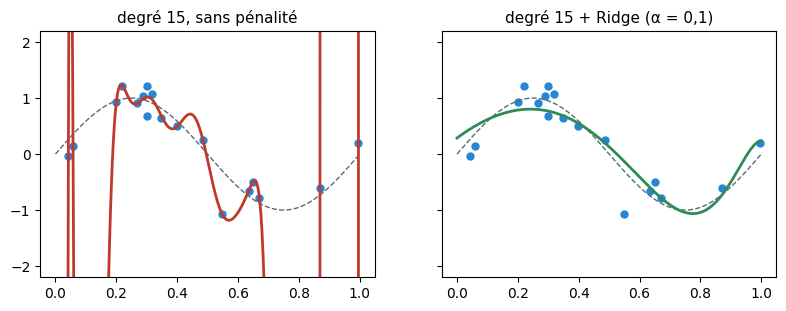

In [36]:
# Avant / après, en image
ridge_01 = make_pipeline(PolynomialFeatures(15), StandardScaler(),
                         Ridge(alpha=0.1)).fit(x_tr.reshape(-1, 1), y_tr)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
for ax, m, titre, c in [(axes[0], sans_penalite, "degré 15, sans pénalité", "#C0392B"),
                        (axes[1], ridge_01, "degré 15 + Ridge (α = 0,1)", "#2E8B57")]:
    ax.scatter(x_tr, y_tr, s=25, color="#2585D6")
    ax.plot(grille, np.sin(2*np.pi*grille), color="#5A6B75", ls="--", lw=1)
    ax.plot(grille, m.predict(grille.reshape(-1, 1)), color=c, lw=2)
    ax.set_ylim(-2.2, 2.2); ax.set_title(titre, fontsize=11)
plt.show()

**Lecture.** Sans pénalité : un coefficient à $9$ milliards et une validation à $1386$.
Avec $\alpha = 0{,}001$ : coefficients sous $8$, validation à $0{,}31$. À $\alpha = 0{,}1$,
le degré 15 régularisé ($0{,}268$) fait même **mieux que le meilleur degré sans pénalité**
($0{,}287$). Et à $\alpha = 100$, le modèle bridé sous-ajuste ($0{,}51$) : $\alpha$ est un
bouton de complexité, comme le degré — il se règle donc sur la **validation**.

**Exercice.** Reprendre la boucle Ridge avec $\alpha = 1000$ : afficher le plus grand
$|w_j|$ et la RMSE de validation. Vers quel modèle la courbe se dirige-t-elle quand
$\alpha$ devient immense ?

In [ ]:
# Ridge avec alpha = 1000 : max|w|, RMSE validation, interprétation

## Mini-défi — Et si on régressait... une classe ?

Le paludisme vaut $0$ ou $1$. Une régression linéaire accepte volontiers cette cible —
voyons ce que ça donne, et pourquoi ce TP s'arrête juste avant la Séance 6.

sorties du modèle : min = 0.008 · max = 0.248


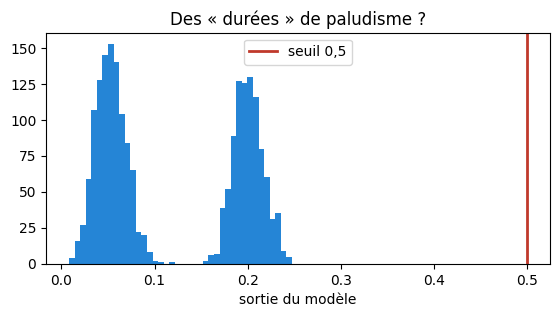

In [38]:
# Une régression linéaire sur la cible paludisme (0/1)
X_palu = df[colonnes]
y_palu = df["paludisme"]
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_palu, y_palu, test_size=0.2,
                                              random_state=42, stratify=y_palu)
reg_palu = LinearRegression().fit(Xp_tr, yp_tr)
sorties = reg_palu.predict(Xp_te)
print("sorties du modèle : min =", round(sorties.min(), 3), "· max =", round(sorties.max(), 3))

plt.figure(figsize=(6.5, 3))
plt.hist(sorties, bins=40, color="#2585D6")
plt.axvline(0.5, color="#C0392B", lw=2, label="seuil 0,5")
plt.xlabel("sortie du modèle"); plt.legend(); plt.title("Des « durées » de paludisme ?")
plt.show()

In [39]:
# Seuiller à 0,5 pour en faire une classe... et comparer à la baseline
from sklearn.metrics import accuracy_score

classes_predites = (sorties >= 0.5).astype(int)
print("positifs prédits :", classes_predites.sum(), "sur", len(classes_predites))
print("accuracy du modèle seuillé :", accuracy_score(yp_te, classes_predites))
print("accuracy de la baseline « jamais palu » :",
      round(accuracy_score(yp_te, np.zeros_like(yp_te)), 4))

positifs prédits : 0 sur 2000
accuracy du modèle seuillé : 0.8825
accuracy de la baseline « jamais palu » : 0.8825


**Lecture.** Les sorties plafonnent à $0{,}25$ : seuillées à $0{,}5$, elles ne
prédisent **aucun** positif — et l'accuracy retombe exactement sur la baseline $0{,}8825$
de la Séance 3. La régression linéaire n'est pas l'outil d'une classe : sa sortie n'est
même pas bornée entre $0$ et $1$, et la MSE n'est pas la bonne façon de la juger sur une
classe rare ($11{,}8\,\%$ de positifs).

**Séance 6 :** la régression *logistique* — la même somme pondérée, passée dans une
fonction qui en fait une probabilité — un **seuil** que l'on choisit, et des métriques
qui ne mentent pas quand une classe est rare.

## Synthèse — à compléter

1. L'équation normale donne le minimum **..........** de la MSE ; la descente de gradient
   l'approche par **..........** successifs.
2. Le gradient pointe vers la plus forte **..........** ; on avance donc dans le sens
   **..........**, avec un pas $\eta$ ni trop petit (lent) ni trop grand (**..........**).
3. MAE et RMSE s'expriment en **..........** ; la RMSE surtaxe les **..........** erreurs ;
   le R² compare le modèle à la **..........**.
4. La RMSE de train **..........** toujours avec la complexité ; le bon degré se lit au
   creux du U de **..........**.
5. Ridge pénalise la **..........** des coefficients ; son bouton $\alpha$ se règle sur la
   validation, et il exige des variables **..........** (Séance 4).